In [2]:
# compile results
import pickle

homedir = "/mnt/mirabelle/az6922_homedir/"
cm_list = ["unv1","prv1"]
nfaillinks_list_dict = dict()
nfaillinks_list_dict["leafspine_before"] = [40,81,122,163,204]
nfaillinks_list_dict["dringsu2_before"] = [42,85,127,170,213]
nfaillinks_list_dict["dringsu2_after"] = [42,85,127,170,213]
fseed_list = range(10)
scheme_list = ["leafspine_before","dringsu2_before","dringsu2_after"]
failpct_list = [0,2,4,6,8,10]
load_dict = dict()
load_dict["unv1"] = 2 #4
load_dict["prv1"] = 2 #3
seed = 1

In [ ]:
import os

cm_topickle_list = []
sumfile = "fct_summary.txt"
datadict = dict()
with open(sumfile,'a') as fw:
    for cm in cm_topickle_list:
        for scheme in scheme_list:
            for nfaillinks in nfaillinks_list_dict[scheme]:
                for fseed in fseed_list:
                    outfile = f"{cm}/outfiles/{scheme}_nfaillinks{nfaillinks}_fseed{fseed}.out"
                    if os.path.exists(outfile):
                        durationlist = list()
                        sizelist = list()
                        startlist = list()
                        with open(outfile,'r') as fr:
                            lines = fr.readlines()
                            for line in lines:
                                tokens = line.split()
                                if tokens[0] == "FCT":
                                    durationlist.append(float(tokens[2]))
                                    sizelist.append(int(tokens[1]))
                                    startlist.append(float(tokens[3]))
                        durationlist.sort()
                        datadict[outfile] = [durationlist,sizelist,startlist]
                        
                        fw.write(f"{outfile}\t{sum(durationlist)/len(durationlist)}\t{durationlist[int(len(durationlist)*0.5)]}\t{durationlist[int(len(durationlist)*0.99)]}\t{durationlist[int(len(durationlist)*0.9999)]}\n")

        # intentional -- repeatedly save current progress
        with open(f'{homedir}az6922_homedir_data/starfish_nsdi26fall_pickle/eval_failure_link.pickle', 'wb') as handle:
            pickle.dump(datadict, handle, protocol=pickle.HIGHEST_PROTOCOL)

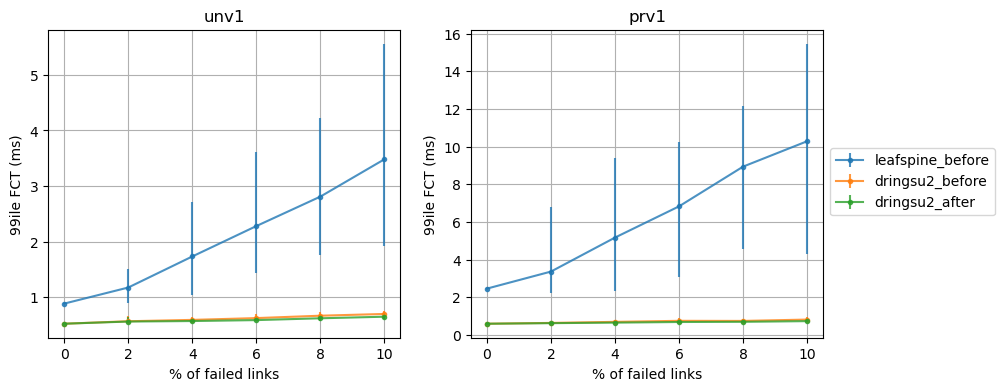

In [4]:
# plot from txt instead of pickle -- pickle files are too large
import matplotlib.pyplot as plt
import numpy as np

plotdatadict = dict()
sumfile = "fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotdatadict:
            plotdatadict[cm] = dict()
        plotdatadict[cm][outfile] = p99

plotevalmaindatadict = dict()
sumfile = "../eval_main/fct_summary.txt"
with open(sumfile,'r') as f:
    # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
    lines = f.readlines()
    for line in lines:
        tokens = line.split()
        outfile = tokens[0]
        outfiletokens = outfile.split('/')
        cm = outfiletokens[0]
        avg = float(tokens[1])
        p50 = float(tokens[2])
        p99 = float(tokens[3])
        p9999 = float(tokens[4])

        if cm not in plotevalmaindatadict:
            plotevalmaindatadict[cm] = dict()
        plotevalmaindatadict[cm][outfile] = p99


markerlist = ['o','x']
nr = 1
nc = len(cm_list)
fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*4))
for ic,cm in enumerate(cm_list):
    for scheme in scheme_list:
        fct_list = list()
        load = load_dict[cm]
        fct_list_allseeds = list()
        if "dring" in scheme:
            myscheme = "dringsu2"
        else:
            myscheme = "leafspine"
        outfile = f"{cm}/outfiles/{myscheme}_load{load}_seed{seed}.out"
        p99 = plotevalmaindatadict[cm][outfile]
        fct_list_allseeds.append(p99)
        fct_list.append(fct_list_allseeds)

        for nfaillinks in nfaillinks_list_dict[scheme]:
            fct_list_allseeds = list()
            for fseed in fseed_list:
                outfile = f"{cm}/outfiles/{scheme}_nfaillinks{nfaillinks}_fseed{fseed}.out"
                p99 = plotdatadict[cm][outfile]
                fct_list_allseeds.append(p99)
            fct_list.append(fct_list_allseeds)
        
        if ic==0:
            axs[ic].errorbar(failpct_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker='.', label=scheme,alpha=0.8)
        else:
            axs[ic].errorbar(failpct_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker='.',alpha=0.8)

    axs[ic].set_xlabel("% of failed links")
    axs[ic].set_ylabel("99ile FCT (ms)")
    axs[ic].set_title(cm)
    axs[ic].grid(True)
fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

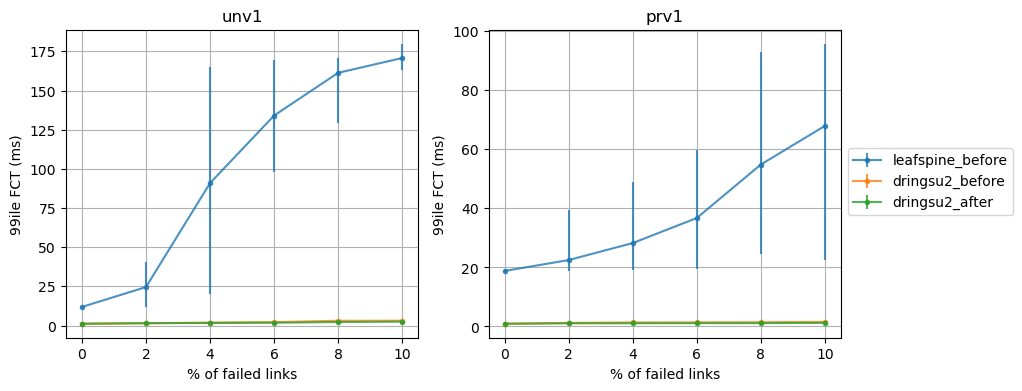

In [ ]:
# # plot from txt instead of pickle -- pickle files are too large
# import matplotlib.pyplot as plt
# import numpy as np

# plotdatadict = dict()
# sumfile = "fct_summary.txt"
# with open(sumfile,'r') as f:
#     # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
#     lines = f.readlines()
#     for line in lines:
#         tokens = line.split()
#         outfile = tokens[0]
#         outfiletokens = outfile.split('/')
#         cm = outfiletokens[0]
#         avg = float(tokens[1])
#         p50 = float(tokens[2])
#         p99 = float(tokens[3])
#         p9999 = float(tokens[4])

#         if cm not in plotdatadict:
#             plotdatadict[cm] = dict()
#         plotdatadict[cm][outfile] = p99

# plotevalmaindatadict = dict()
# sumfile = "../eval_main/fct_summary.txt"
# with open(sumfile,'r') as f:
#     # cluster_a/outfiles/rrgsu2_load6_seed2.out	0.05765561435997601	0.0487378	0.169153	0.746218
#     lines = f.readlines()
#     for line in lines:
#         tokens = line.split()
#         outfile = tokens[0]
#         outfiletokens = outfile.split('/')
#         cm = outfiletokens[0]
#         avg = float(tokens[1])
#         p50 = float(tokens[2])
#         p99 = float(tokens[3])
#         p9999 = float(tokens[4])

#         if cm not in plotevalmaindatadict:
#             plotevalmaindatadict[cm] = dict()
#         plotevalmaindatadict[cm][outfile] = p99


# markerlist = ['o','x']
# nr = 1
# nc = len(cm_list)
# fig, axs =plt.subplots(nr, nc, figsize=(nc*5, nr*4))
# for ic,cm in enumerate(cm_list):
#     for scheme in scheme_list:
#         fct_list = list()
#         load = load_dict[cm]
#         fct_list_allseeds = list()
#         if "dring" in scheme:
#             myscheme = "dringsu2"
#         else:
#             myscheme = "leafspine"
#         outfile = f"{cm}/outfiles/{myscheme}_load{load}_seed{seed}.out"
#         p99 = plotevalmaindatadict[cm][outfile]
#         fct_list_allseeds.append(p99)
#         fct_list.append(fct_list_allseeds)

#         for nfaillinks in nfaillinks_list_dict[scheme]:
#             fct_list_allseeds = list()
#             for fseed in fseed_list:
#                 outfile = f"{cm}/outfiles/{scheme}_nfaillinks{nfaillinks}_fseed{fseed}.out"
#                 p99 = plotdatadict[cm][outfile]
#                 fct_list_allseeds.append(p99)
#             fct_list.append(fct_list_allseeds)
        
#         if ic==0:
#             axs[ic].errorbar(failpct_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker='.', label=scheme,alpha=0.8)
#         else:
#             axs[ic].errorbar(failpct_list, [sum(x)/len(x) for x in fct_list], yerr=[[sum(x)/len(x)-min(x) for x in fct_list],[max(x)-sum(x)/len(x) for x in fct_list]], marker='.',alpha=0.8)

#     axs[ic].set_xlabel("% of failed links")
#     axs[ic].set_ylabel("99ile FCT (ms)")
#     axs[ic].set_title(cm)
#     axs[ic].grid(True)
# fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))